# $$ \textbf{Sinais e Sistemas Dinâmicos}$$

## $$ \textbf{Lista 2 - 09 de setembro de 2024}$$


In [1]:
## Importação das bibliotecas Python, como indicado no texto ##

# biblioteca Python para matemática simbólica 
import sympy as sym
from sympy import * 

# Pacote para computação científica
import numpy as np

# biblioteca para a visualização de dados em Python.
import matplotlib.pyplot as plt

# Este módulo fornece acesso às funções matemáticas (definidas pelo padrão C)
import math

# cmath permite operações com números complexos
import cmath

# O módulo de frações fornece suporte para aritmética de números racionais
from fractions import Fraction

# permite usar latex para exibir equações matemáticas no Jupyter Notebook
from IPython.display import display, Math

### Questão 1: 
Para cada um dos sinais periódicos mostrados na Fig. P6.6-1, determine a série trigonométrica compacta de Fourier e trace o espectro de amplitude e fase. Se os termos em seno ou cosseno estiverem ausentes da série de Fourier, explique.

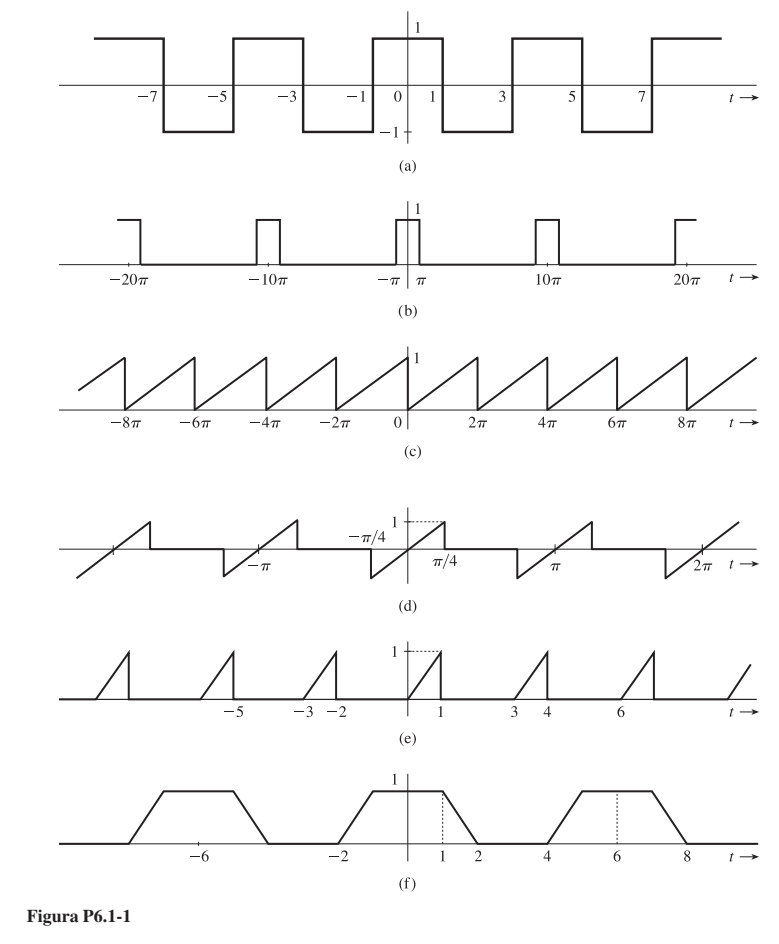

### Solução:

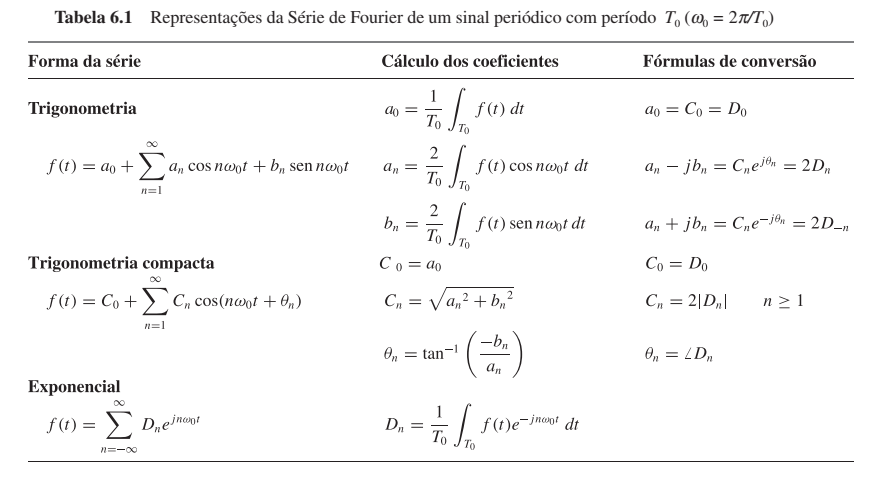

### Solução:

#### a)


In [2]:
t = symbols('t')
g = sym.Piecewise((-1, (-2 <= t) & (t <=-1)),(1, (-1 <= t) & (t <=1)),(-1, (1 <= t) & (t <=2)), (0, True))
s = fourier_series(g, (t, -2, 2))
s1 = s.truncate(n = 2)
s2 = s.truncate(n = 5)
s3 = s.truncate(n = 20)
s4 = s.truncate(n = 50)


p1 = sym.plot(g, s1, (t, -2, 2), title='Exercício 1.a - $m=2$', show=False, legend=True)
p2 = sym.plot(g, s2, (t, -2, 2), title='Exercício 1.a - $m=5$', show=False, legend=True)
p3 = sym.plot(g, s3, (t, -2, 2), title='Exercício 1.a - $m=20$', show=False, legend=True)
p4 = sym.plot(g, s4, (t, -2, 2), title='Exercício 1.a - $m=50$', show=False, legend=True)

p1[0].line_color = 'b'
p1[0].label = '$g(t)$'
p2[0].line_color = 'b'
p2[0].label = '$g(t)$'
p3[0].line_color = 'b'
p3[0].label = '$g(t)$'
p4[0].line_color = 'b'
p4[0].label = '$g(t)$'
p1[1].line_color = 'r'
p1[1].label = 'm=2'
p2[1].line_color = 'r'
p2[1].label = 'm=5'
p3[1].line_color = 'r'
p3[1].label = 'm=20'
p4[1].line_color = 'r'
p4[1].label = 'm=50'

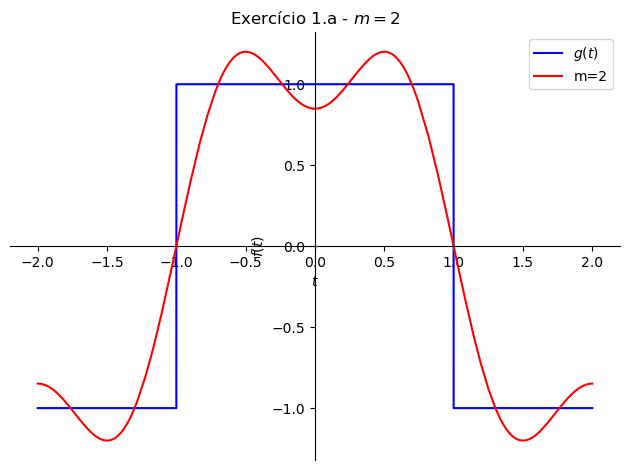

In [3]:
p1.show()

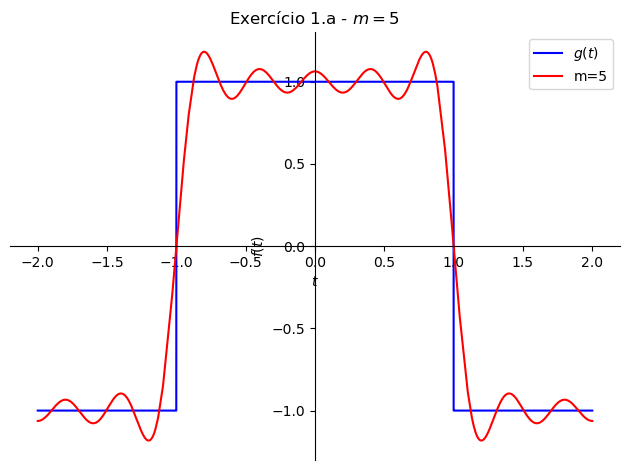

In [4]:
p2.show()

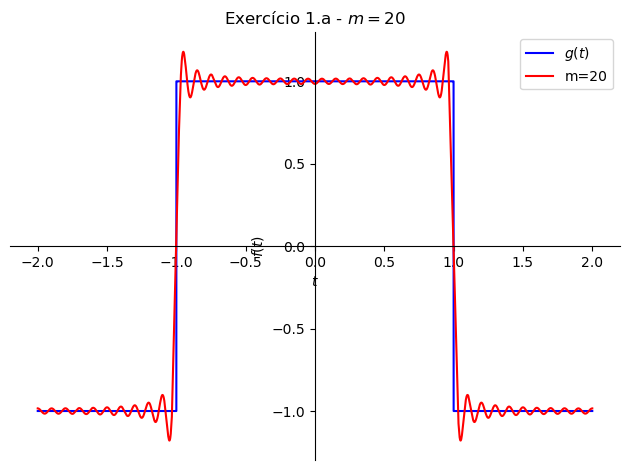

In [5]:
p3.show()

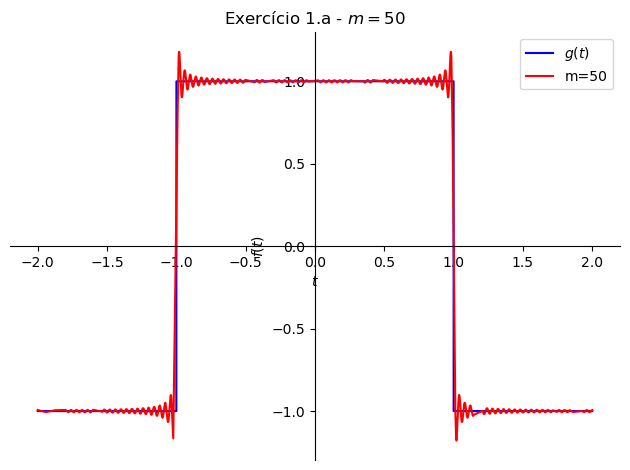

In [6]:
p4.show()

In [15]:
s

FourierSeries(Piecewise((-1, (t >= -2) & (t <= -1)), (1, (t >= -1) & (t <= 1)), (-1, (t >= 1) & (t <= 2)), (0, True)), (t, -2, 2), (0, SeqFormula(Piecewise((8*sin(_n*pi/2)/(_n*pi) - 4*sin(_n*pi)/(_n*pi), (_n > -oo) & (_n < oo) & Ne(_n, 0)), (0, True))*cos(_n*pi*t/2)/2, (_n, 1, oo)), SeqFormula(0, (_n, 1, oo))))

Por uma simples inspeção, podemos inferir que 

$$
a_0 = b_n = 0, \quad \forall n \in \mathbb{N}
$$
e que, 

$$
a_n = \begin{cases}
(-1)^n \frac{4}{n \pi}, \quad \text{para n ímpar,}\\
0, \quad \text{para n par,}
\end{cases}
$$

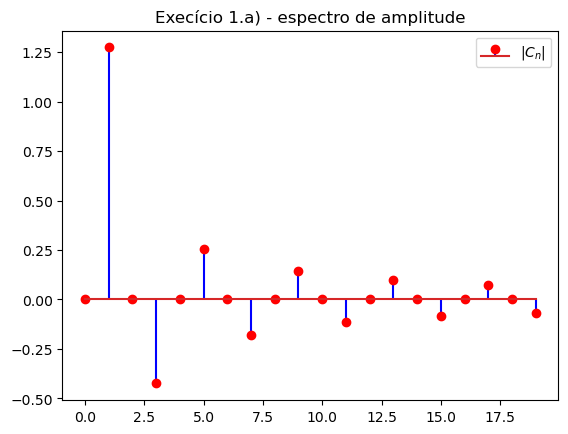

In [60]:
t = symbols('t')
z = []
a = []
b = []
th = []
for n in range(0,20):
    z.append(n)
    a.append((s[n].subs(t,0)))
    b.append(0)
    if s[n].subs(t,0) < 0:
        th.append(-pi)
    else:
        th.append(0)
        

     
plt.stem(z, a, 'b', markerfmt='ro', label='$|C_n|$')
plt.legend()
plt.title('Execício 1.a) - espectro de amplitude')
plt.show()

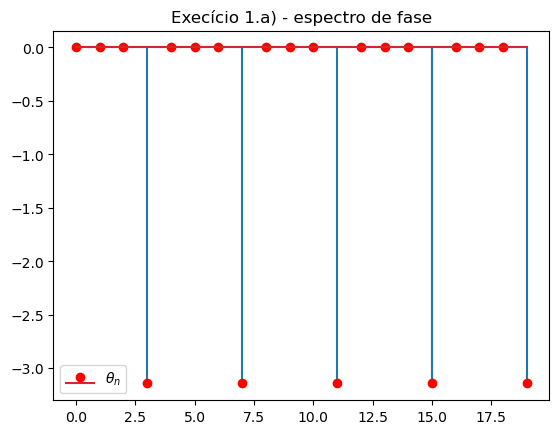

In [63]:
plt.stem(z, th, markerfmt='ro', label='$\\theta_n$')
plt.legend()
plt.title('Execício 1.a) - espectro de fase')
plt.show()

#### b)


In [33]:
T0, t = symbols('T0 t', real = True)
T0 = 10*pi
a0 = integrate(1,(t,-pi,pi))/T0
a0

1/5

In [35]:
T0, t = symbols('T0 t', real = True)
n = symbols('n', integer = True, positive = True)

T0 = 10*pi
w0 = 2*pi/T0
an = simplify((2/T0)*integrate(1*cos(n*w0*t),(t,-pi,pi)))
an

2*sin(pi*n/5)/(pi*n)

In [36]:
T0, t = symbols('T0 t', real = True)
n = symbols('n', integer = True, positive = True)

T0 = 10*pi
w0 = 2*pi/T0
bn = simplify((2/T0)*integrate(1*sin(n*w0*t),(t,-pi,pi)))
bn

0

In [37]:
Cn = sqrt(an**2 + bn**2)
Cn

2*Abs(sin(pi*n/5))/(pi*n)

In [41]:
phin = atan(-bn/an)
phin

0

$$
f(t) = \frac{1}{5} + \sum_{n=1}^{\infty} \frac{2 |sin\left(\pi n / 5\right) |}{\pi n}cos\left(nt/5 \right)
$$

*c)*
$$
u(t) = t/2\pi, \quad 2 \pi \text{ periódico}
$$

In [42]:
T0, t = symbols('T0 t', real = True)
T0 = 2*pi
a0 = integrate(t/(2*pi),(t,0,2*pi))/T0
a0

1/2

In [48]:
T0, t = symbols('T0 t', real = True)
n = symbols('n', integer = True, positive = True)

T0 = 2*pi
w0 = 2*pi/T0
an = ((2/T0)*integrate((t/(2*pi))*cos(n*w0*t),(t,0,2*pi)))
an

0

In [45]:
T0, t = symbols('T0 t', real = True)
n = symbols('n', integer = True, positive = True)

T0 = 2*pi
w0 = 2*pi/T0
bn = simplify((2/T0)*integrate((t/(2*pi))*sin(n*w0*t),(t,0,2*pi)))
bn

-1/(pi*n)

In [51]:
phin = atan(-bn/an)
phin

AccumBounds(-pi/2, pi/2)

$$
f(t) = 0 +  \sum_{n=1}^{\infty} \frac{1}{\pi n}cos\left(nt + \frac{\pi}{2} \right)
$$

### Questão 2: 

Se as duas metades de um período de um sinal periódico são idênticas em forma exceto que uma é o negativo da outra, o sinal periódico é dito ter simetria de meia onda. Se um sinal periódico $x(t)$ com período $T_0$ satisfaz a condição de simetria de meia onda, então

$$
x\left(t-\frac{T_0}{2}\right)=-x(t)
$$


Neste caso, mostre que toda harmônica de número par desaparece e que os coeficientes das harmônicas de número ímpar são dados por

$$
a_n=\frac{4}{T_0} \int_0^{T_0 / 2} x(t) \cos n \omega_0 t d t
$$

e

$$
b_n=\frac{4}{T_0} \int_0^{T_0 / 2} x(t) \operatorname{sen} n \omega_0 t d t
$$


Usando esses resultados, obtenha a série de Fourier para os sinais periódicos da Fig. P6.1-5.


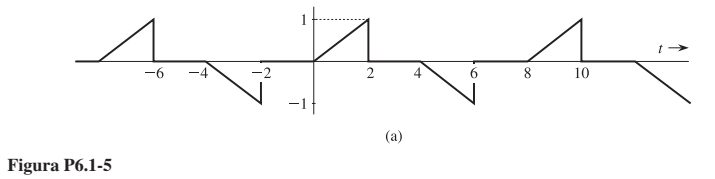

### Questão 3: 

Em um intervalo finito, um sinal pode ser representado por mais do que uma série de Fourier trigonométrica (ou exponencial). Por exemplo, se quisermos representar $x(t)=t$ em um intervalo $0<t<1$ por uma série de Fourier com freqüência fundamental $\omega_0=2$, podemos desenhar um pulso $x(t)=t$ no intervalo $0<t<1$ e repetir o pulso a cada $\pi$ segundos, tal que $T_0=\pi$ e $\omega_0=2$ (Fig. P6.16a). 

Se quisermos que a freqüência fundamental $\omega_0$ seja 4 , repetimos o pulso a cada $\pi / 2$ segundos. Se quisermos que a série contenham apenas termos em cosseno com $\omega_0=2$, construímos o pulso $x(t)=|t|$ em $-1<t<1$ e o repetimos a cada $\pi$ segundos (Fig. 6.1-6b). 

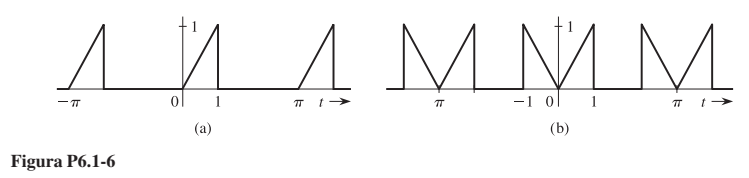

O sinal resultante será uma função par com período $\pi$. Logo, sua série de Fourier terá apenas termos em cosseno com $\omega_0=2$. A série de Fourier resultante representa $x(t)=t \mathrm{em} 0$ $<t<1$, como desejado. Não precisamos nos preocupar com o que ela representa fora desse intervalo.

Trace um sinal periódico $x(t)$ tal que $x(t)=t$ para $0<t<1$ e que a série de Fourier para $x(t)$ satisfaça as seguintes condições.

(a) $\omega_0=\pi / 2$ e contenha todas as harmônicas, mas apenas termos em cosseno.

(b) $\omega_0=2$ e contenha todas as harmônicas, mas apenas termos em seno.

(c) $\omega_0=\pi / 2$ e contenha todas as harmônicas que não sejam exclusivamente senos ou cossenos.

(d) $\omega_0=1$ e contenha apenas harmônicas ímpares e termos em cosseno.

(e) $\omega_0=\pi / 2$ e contenha apenas harmônicas ímpares, mas apenas termos em seno.

(f) $\omega_0=1$ e contenha apenas harmônicas ímpares que não sejam exclusivamente senos ou cossenos.

[Dica: para as partes (d), (e) e (f), você precisará utilizar a simetria de meia onda discutida no Prob. 6.1-5. Termos em cosseno implicam possível componente cc.]
Você deve apenas traçar o sinal periódico $x(t)$ que satisfaça as condições dadas. Não determine os valores dos coeficientes de Fourier.

### Questão 4: 

Um sinal periódico $x(t)$ é descrito pela seguinte série de Fourier:

$$
x(t)=3 \cos t+\operatorname{sen}\left(5 t-\frac{\pi}{6}\right)-2 \cos \left(8 t-\frac{\pi}{3}\right)
$$

(a) Trace o espectro de amplitude e fase para a série trigonométrica.

(b) Por inspeção do espectro da parte (a), trace o espectro da série exponencial de Fourier.

(c) Por inspeção do espectro da parte (b), escreva a série exponencial de Fourier de $x(t)$.

(d) Mostre que série determinada na parte (c) é equivalente à série trigonométrica de $x(t)$.

### Questão 5: 

A Fig. P6.3-6 mostra o espectro trigonométrico de Fourier de um sinal periódico $x(t)$.

(a) Por inspeção da Fig. P6.3-6, determine a série trigonométrica de Fourier que representa $x(t)$.

(b) Por inspeção da Fig. P6.3-6, trace o espectro exponencial de Fourier de $x(t)$.

(c) Por inspeção do espectro exponencial de Fourier obtido na parte (b), determine a série exponencial de Fourier de $x(t)$.

(d) Mostre que as séries determinadas nas partes (a) e (c) são equivalentes.


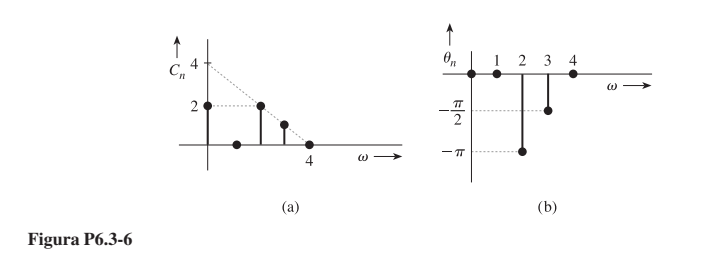

### Questão 6: 

(a) Determine a série exponencial de Fourier para o sinal $x(t)=\cos 5 t \operatorname{sen} 3 t$. Você pode obtê-la sem calcular nenhuma integral.

(b) Trace o espectro de Fourier.

(c) O sinal $x(t)$ é aplicado a entrada de um sistema LCIT com resposta em freqüência mostrada na Fig. P6.4-2. Obtenha a saída $y(t)$.

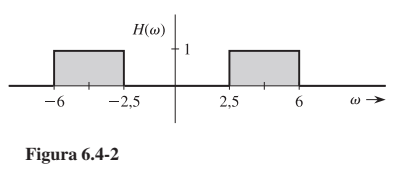

### Questão 7: 

(a) Determine a série exponencial de Fourier para um sinal periódico $x(t)$ mostra na Fig. P6.4-3a.

(b) O sinal $x(t)$ é aplicado a entrada do sistema LCIT mostrado na Fig. P6.4-3b. Determine a expressão para a saída $y(t)$.

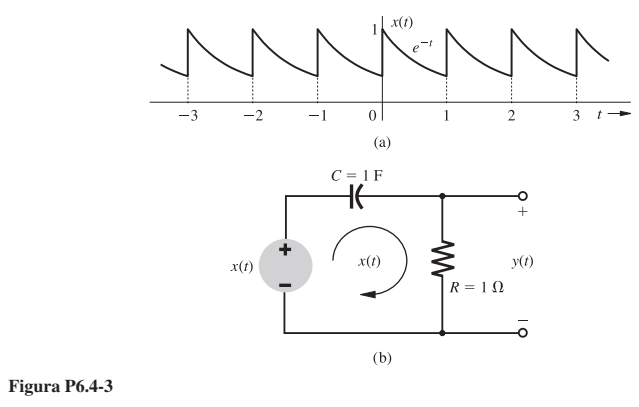

### Questão 8: 

Obtenha a transformada de Fourier de $x(t)=\operatorname{ret}(t / \tau)$. Trace o espectro de amplitude $|X(\omega)|$ e o espectro de fase $\angle X(\omega)$.

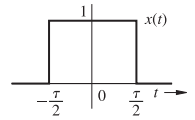

## Solução:

Como ret $(t / \tau)=1$ para $|t|<\tau / 2$ e zero para $|t|>\tau / 2$,

$$
\begin{aligned}
X(\omega) & =\int_{-\tau / 2}^{\tau / 2} e^{-j \omega t} d t \\
& =-\frac{1}{j \omega}\left(e^{-j \omega \tau / 2}-e^{j \omega \tau / 2}\right)=\frac{2 \operatorname{sen}\left(\frac{\omega \tau}{2}\right)}{\omega} \\
& =\tau \frac{\operatorname{sen}\left(\frac{\omega \tau}{2}\right)}{\left(\frac{\omega \tau}{2}\right)}=\tau \operatorname{sinc}\left(\frac{\omega \tau}{2}\right)
\end{aligned}
$$


Portanto,

$$
\operatorname{ret}\left(\frac{t}{\tau}\right) \Longleftrightarrow \tau \operatorname{sinc}\left(\frac{\omega \tau}{2}\right)
$$


In [13]:
w, t, tau = symbols('w t tau', real = True, zero = False)
aux8 = simplify(integrate(exp(-1J*w*t), (t,-tau/2,tau/2)))
aux8

2.0*sin(0.5*tau*w)/w

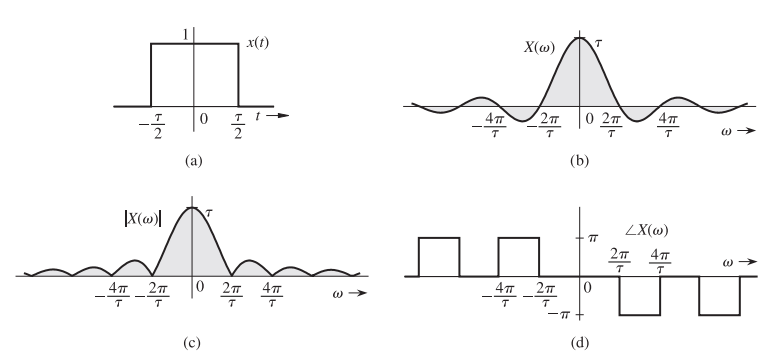

### Questão 9: 

Obtenha a transformada de Fourier par ao impulso unitário $\delta(t).$

#### Solução:

Usando a propriedade de amostragem do impulso, obtemos

$$
\mathcal{F}[\delta(t)]=\int_{-\infty}^{\infty} \delta(t) e^{-j \omega t} d t=1
$$

ou

$$
\delta(t) \Longleftrightarrow 1
$$


In [16]:
w, t = symbols('w t', real = True)
aux9 = simplify(integrate(exp(-1J*w*t)*DiracDelta(t), (t,-oo,oo)))
aux9

1

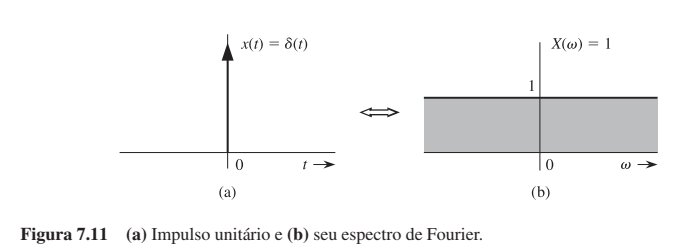

### Questão 10: 

Obtenha a transformada de Fourier inversa de $\delta(\omega)$.

### Solução:


$$
\mathcal{F}^{-1}[\delta(\omega)]=\frac{1}{2 \pi} \int_{-\infty}^{\infty} \delta(\omega) e^{j \omega t} d \omega=\frac{1}{2 \pi}
$$


Portanto,

$$
\frac{1}{2 \pi} \Longleftrightarrow \delta(\omega)
$$

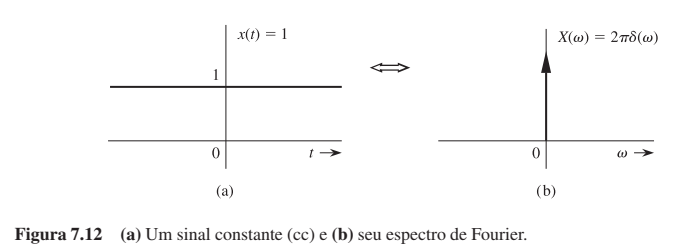


In [18]:
w, t = symbols('w t', real = True)
aux10 = simplify(integrate(exp(1J*w*t)*DiracDelta(w)/(2*pi), (w,-oo,oo)))
aux10

1/(2*pi)

### Questão 11: 

Obtenha a transformada de Fourier inversa de $\delta\left(\omega-\omega_0\right)$.

### Solução:

Usando a propriedade de amostragem da função impulso, obtemos

$$
\mathcal{F}^{-1}\left[\delta\left(\omega-\omega_0\right)\right]=\frac{1}{2 \pi} \int_{-\infty}^{\infty} \delta\left(\omega-\omega_0\right) e^{j \omega t} d \omega=\frac{1}{2 \pi} e^{j \omega_0 t}
$$


Portanto,

$$
\frac{1}{2 \pi} e^{j \omega_0 t} \Longleftrightarrow \delta\left(\omega-\omega_0\right)
$$

ou

$$
e^{j \omega_0 t} \Longleftrightarrow 2 \pi \delta\left(\omega-\omega_0\right)
$$


In [21]:
w, w0, t = symbols('w w0 t', real = True)
aux11 = simplify(integrate(exp(1J*w*t)*DiracDelta(w - w0)/(2*pi), (w,-oo,oo)))
aux11

exp(1.0*I*t*w0)/(2*pi)

Assim, temos que 

$$
e^{j \omega_0 t} \Longleftrightarrow 2 \pi \delta\left(\omega-\omega_0\right)
$$
e
$$
e^{-j \omega_0 t} \Longleftrightarrow 2 \pi \delta\left(\omega+\omega_0\right)
$$

### Questão 12: 

Obtenha a transformada de Fourier da senoide de duração infinita $\cos \omega_0 t$.


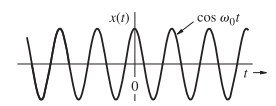

### Solução:

Da fórmula de Euler,

$$
\cos \omega_0 t=\frac{1}{2}\left(e^{j \omega_0 t}+e^{-j \omega_0 t}\right)
$$


Usando o resultado anterior, obtemos

$$
\cos \omega_0 t \Longleftrightarrow \pi\left[\delta\left(\omega+\omega_0\right)+\delta\left(\omega-\omega_0\right)\right]
$$


### Questão 13: 

Obtenha a transformada de Fourier da função degrau unitário $u(t)$.

### Solução:

Se tentarmos obter a transformada de Fourier de $u(t)$ diretamente pela integração, teremos um resultado indeterminado porque

$$
U(\omega)=\int_{-\infty}^{\infty} u(t) e^{-j \omega t} d t=\int_0^{\infty} e^{-j \omega t} d t=\left.\frac{-1}{j \omega} e^{-j \omega t}\right|_0 ^{\infty}
$$


O limite superior de $e^{-j \omega t}$ quando $t \rightarrow \infty$ resulta em uma resposta indeterminada. Logo, abordamos esse problema considerando $u(t)$ como sendo a exponencial decrescente $e^{-a t} u(t)$ no limite quando $a \rightarrow 0$ (figura abaixo). 

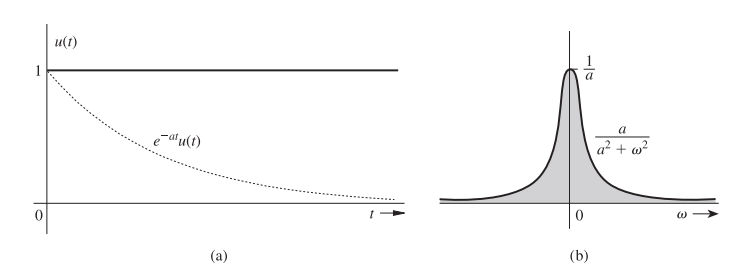

Logo,

$$
u(t)=\lim _{a \rightarrow 0} e^{-a t} u(t)
$$

e

$$
U(\omega)=\lim _{a \rightarrow 0} \mathcal{F}\left\{e^{-a t} u(t)\right\}=\lim _{a \rightarrow 0} \frac{1}{a+j \omega}
$$


Expressar o lado direito em termos de sua parte real e imaginária resulta em

$$
\begin{aligned}
U(\omega) & =\lim _{a \rightarrow 0}\left[\frac{a}{a^2+\omega^2}-j \frac{\omega}{a^2+\omega^2}\right] \\
& =\lim _{a \rightarrow 0}\left[\frac{a}{a^2+\omega^2}\right]+\frac{1}{j \omega}
\end{aligned}
$$


A função $a /\left(a^2+\omega^2\right)$ possui propriedades interessantes. Primeiro, a área sob essa função (Fig. 7.15b) é $\pi$, independente do valor de $a$ :

$$
\int_{-\infty}^{\infty} \frac{a}{a^2+\omega^2} d \omega=\left.\tan ^{-1} \frac{\omega}{a}\right|_{-\infty} ^{\infty}=\pi
$$


Segundo, quando $a \rightarrow 0$, esta função aproxima-se de zero para todo $\omega \neq 0$ e toda a sua área ( $\pi$ ) estará concentrada em um único ponto $\omega=0$. Claramente, quando $a \rightarrow 0$, essa função aproxima-se de um impulso com força $\pi.$ Portanto,

$$
U(\omega)=\pi \delta(\omega)+\frac{1}{j \omega}
$$


### Questão 14: 

Obtenha a transformada de Fourier da função sinal sgn $(t)$, mostrada na figura abaixo.


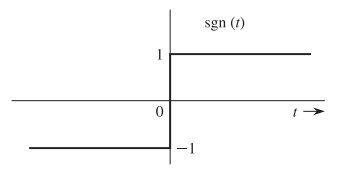

### Questão 15: 

Mostre que a transformada de Fourier inversa de $X(\omega)$ mostrada na figura abaixo é $x(t)=\left(\omega_0 / \pi\right) \operatorname{sinc}\left(\omega_0 t\right)$. Trace $x(t)$

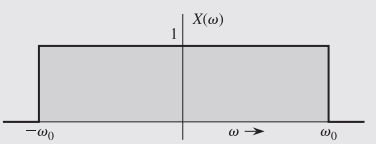

### Questão 16: 

Mostre que $\cos \left(\omega_0 t+\theta\right) \Leftrightarrow \pi\left[\delta\left(\omega+\omega_0\right) e^{-j \theta}+\delta\left(\omega-\omega_0\right) e^{j \theta}\right]$.

### Questão 17: 

Mostre a ``propriedade da dualidade``, que afirma que se

$$
x(t) \Longleftrightarrow X(\omega)
$$

então

$$
X(t) \Longleftrightarrow 2 \pi x(-\omega)
$$


#### Solução:

Da equação 
$$
x(t)=\frac{1}{2 \pi} \int_{-\infty}^{\infty} X(\omega) e^{j \omega t} d \omega
$$

podemos escrever,

$$
x(t)=\frac{1}{2 \pi} \int_{-\infty}^{\infty} X(u) e^{j u t} d u
$$


Logo,

$$
2 \pi x(-t)=\int_{-\infty}^{\infty} X(u) e^{-j u t} d u
$$


Trocando $t$ por $\omega$ obtemos o resultado.

### Questão 18: 

Sabendo que 

 - $e^{-a t} u(t) \Longleftrightarrow \frac{1}{a+j \omega} \quad a>0$
 
 - $e^{-a|t|} \Longleftrightarrow \frac{2 a}{a^2+\omega^2} \quad a>0$
 
 - $\cos \omega_0 t \Longleftrightarrow \pi\left[\delta\left(\omega-\omega_0\right)+\delta\left(\omega+\omega_0\right)\right]$
 
 Use o princípio da dualidade para mostrar que 
 
(a) $1 /($ jt $+a) \Longleftrightarrow 2 \pi e^{a \omega} u(-\omega)$

(b) $2 a /\left(t^2+a^2\right) \Longleftrightarrow 2 \pi e^{-a|\omega|}$

(c) $\delta\left(t+t_0\right)+\delta\left(t-t_0\right) \Longleftrightarrow 2 \cos t_0 \omega$

### Questão 19: 

Demonstre a ``propriedade do escalamento``, que diz que se

$$
x(t) \Longleftrightarrow X(\omega)
$$

então, para qualquer constante real $a$,

$$
x(a t) \Longleftrightarrow \frac{1}{|a|} X\left(\frac{\omega}{a}\right)
$$


#### Prova. 
Para uma constante real positiva $a$,

$$
\begin{aligned}
\mathcal{F}[x(a t)] & =\int_{-\infty}^{\infty} x(a t) e^{-j \omega t} d t \\
& =\frac{1}{a} \int_{-\infty}^{\infty} x(u) e^{(-j \omega / a) u} d u=\frac{1}{a} X\left(\frac{\omega}{a}\right)
\end{aligned}
$$


Similarmente, podemos demonstrar que se $a<0$,

$$
x(a t) \Longleftrightarrow \frac{-1}{a} X\left(\frac{\omega}{a}\right)
$$


### Questão 20: 

Demonstre a ``Propriedade de Deslocamento no Tempo`` que assegura que se

$$
x(t) \Longleftrightarrow X(\omega)
$$

então

$$
x\left(t-t_0\right) \Longleftrightarrow X(\omega) e^{-j \omega t_0}
$$


Utilize esse resultado para obter a transformada de Fourier de $e^{-a\left|t-t_o\right|}$.

#### Prova.

Pela definição,

$$
\mathcal{F}\left[x\left(t-t_0\right)\right]=\int_{-\infty}^\omega x\left(t-t_0\right) e^{-j \omega t} d t
$$


Fazendo $t-t_0=u$, temos

$$
\begin{aligned}
\mathcal{F}\left[x\left(t-t_0\right)\right] & =\int_{-\infty}^{\infty} x(u) e^{-j \omega\left(u+t_0\right)} d u \\
& =e^{-j \omega t_0} \int_{-\infty}^{\infty} x(u) e^{-j \omega u} d u=X(\omega) e^{-j \omega t_0}
\end{aligned}
$$


``Esse resultado mostra que atrasar um sinal por $t_0$ segundos não altera seu espectro de amplitude. $O$ espectro de fase, entretanto, é alterado por $-\omega t_0$.``

### Questão 21:  Demonstre as seguintes propriedades

 
 - i) Deslocamento na frequência $\left(\omega_0\right.$ real ) $x(t) e^{j \omega_0 t}  \Longleftrightarrow X\left(\omega-\omega_0\right)$
 
 - ii) Convolução no tempo $x_1(t) * x_2(t)  \Longleftrightarrow X_1(\omega) X_2(\omega)$  
 
 - iii) Convolução na frequência $x_1(t) x_2(t) \Longleftrightarrow \frac{1}{2 \pi} X_1(\omega) * X_2(\omega)$  
 
 - iv) Diferenciação no tempo $\frac{d^n x}{d t^n} \Longleftrightarrow (j \omega)^n X(\omega)$
 
 - v) Integração no tempo $\int_{-\infty}^t x(u) d u \Longleftrightarrow \frac{X(\omega)}{j \omega}+\pi X(0) \delta(\omega)$


#### Prova i). 

Pela definição

$$
\mathcal{F}\left[x(t) e^{j \omega_0 t}\right]=\int_{-\infty}^{\infty} x(t) e^{j \omega_0 t} e^{-j \omega t} d t=\int_{-\infty}^{\infty} x(t) e^{-j\left(\omega-\omega_0\right) t} d t=X\left(\omega-\omega_0\right)
$$


De acordo com essa propriedade, a multiplicação de um sinal por um fator $e^{j \omega_0 t}$ desloca o espectro do sinal por $\omega=\omega_0$. Note a dualidade entre as propriedades de deslocamento no tempo e deslocamento na frequência.

Trocando $\omega_0$ por $-\omega_0$ resulta em

$$
x(t) e^{-j \omega_0 t} \Longleftrightarrow X\left(\omega+\omega_0\right)
$$


Como $e^{j \omega_0 t}$ não é uma função real que pode ser gerada, o deslocamento na frequência na prática é obtido multiplicando $x(t)$ por uma senóide. Observe que

$$
x(t) \cos \omega_0 t=\frac{1}{2}\left[x(t) e^{j \omega_0 t}+x(t) e^{-j \omega_0 t}\right]
$$


Assim, temos

$$
x(t) \cos \omega_0 t \Longleftrightarrow \frac{1}{2}\left[X\left(\omega-\omega_0\right)+X\left(\omega+\omega_0\right)\right]
$$


#### Prova ii).

Pela definição

$$
\begin{aligned}
\mathcal{F}\left|x_1(t) * x_2(t)\right| & =\int_{-\infty}^{\infty} e^{-j \omega t}\left[\int_{-\infty}^{\infty} x_1(\tau) x_2(t-\tau) d \tau\right] d t \\
& =\int_{-\infty}^{\infty} x_1(\tau)\left[\int_{-\infty}^{\infty} e^{-j \omega t} x_2(t-\tau) d t\right] d \tau
\end{aligned}
$$


A integral interna é a transformada de Fourier de $x_2(t-\tau)$, dada por [propriedade de deslocamento no tempo da Eq. (7.37)] $X_2(\omega) e^{-j \omega t}$. Logo,

$$
\mathcal{F}\left[x_1(t) * x_2(t)\right]=\int_{-\infty}^{\infty} x_1(\tau) e^{-j \omega \tau} X_2(\omega) d \tau=X_2(\omega) \int_{-\infty}^{\infty} x_1(\tau) e^{-j \omega \tau} d \tau=X_1(\omega) X_2(\omega)
$$

seja $H(\omega)$ a transformada de Fourier da resposta ao impulso unitário $h(t)$, ou seja,

$$
h(t) \Longleftrightarrow H(\omega)
$$


A aplicação da propriedade de convolução no tempo a $y(t)=x(t) * h(t)$ resulta em (assumindo que tanto $x(t)$ quanto $h(t)$ possuem suas transformadas de Fourier)

$$
Y(\omega)=X(\omega) H(\omega)
$$


#### Prova iv).

A diferenciação dos dois lados da equação $x(t)=\frac{1}{2 \pi} \int_{-\infty}^{\infty} X(\omega) e^{j \omega t} d \omega$ resulta em

$$
\frac{d x}{d t}=\frac{1}{2 \pi} \int_{-\infty}^{\infty} j \omega X(\omega) e^{j \omega t} d \omega
$$


Esse resultado mostra que


$$
\frac{d x}{d t} \Longleftrightarrow j \omega X(\omega)
$$


A aplicação repetida dessa propriedade leva a

$$
\frac{d^n x}{d t^n} \Longleftrightarrow(j \omega)^n X(\omega)
$$


#### Prova v)

temos que

$$
x(t) * u(t)=\int_{-\infty}^{\infty} x(\tau) u(t-\tau) d \tau=\int_{-\infty}^t x(\tau) d \tau
$$


Agora, da propriedade de convolução no tempo, temos que

$$
\begin{aligned}
x(t) * u(t) & =\int_{-\infty}^t x(\tau) d \tau \Longleftrightarrow X(\omega)\left[\frac{1}{j \omega}+\pi \delta(\omega)\right] \\
& =\frac{X(\omega)}{j \omega}+\pi X(0) \delta(\omega)
\end{aligned}
$$


### Questão 22:

Utilize a propriedade de diferenciação no tempo para obter a transformada de Fourier do pulso triangular $\Delta(t / \tau)$ apresentado abaixo.

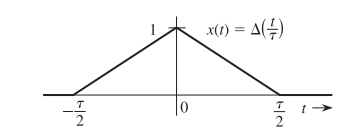

### Questão 23:

Utilize a propriedade de diferenciação no tempo para obter a transformada de Fourier de ret $(t / \tau)$.